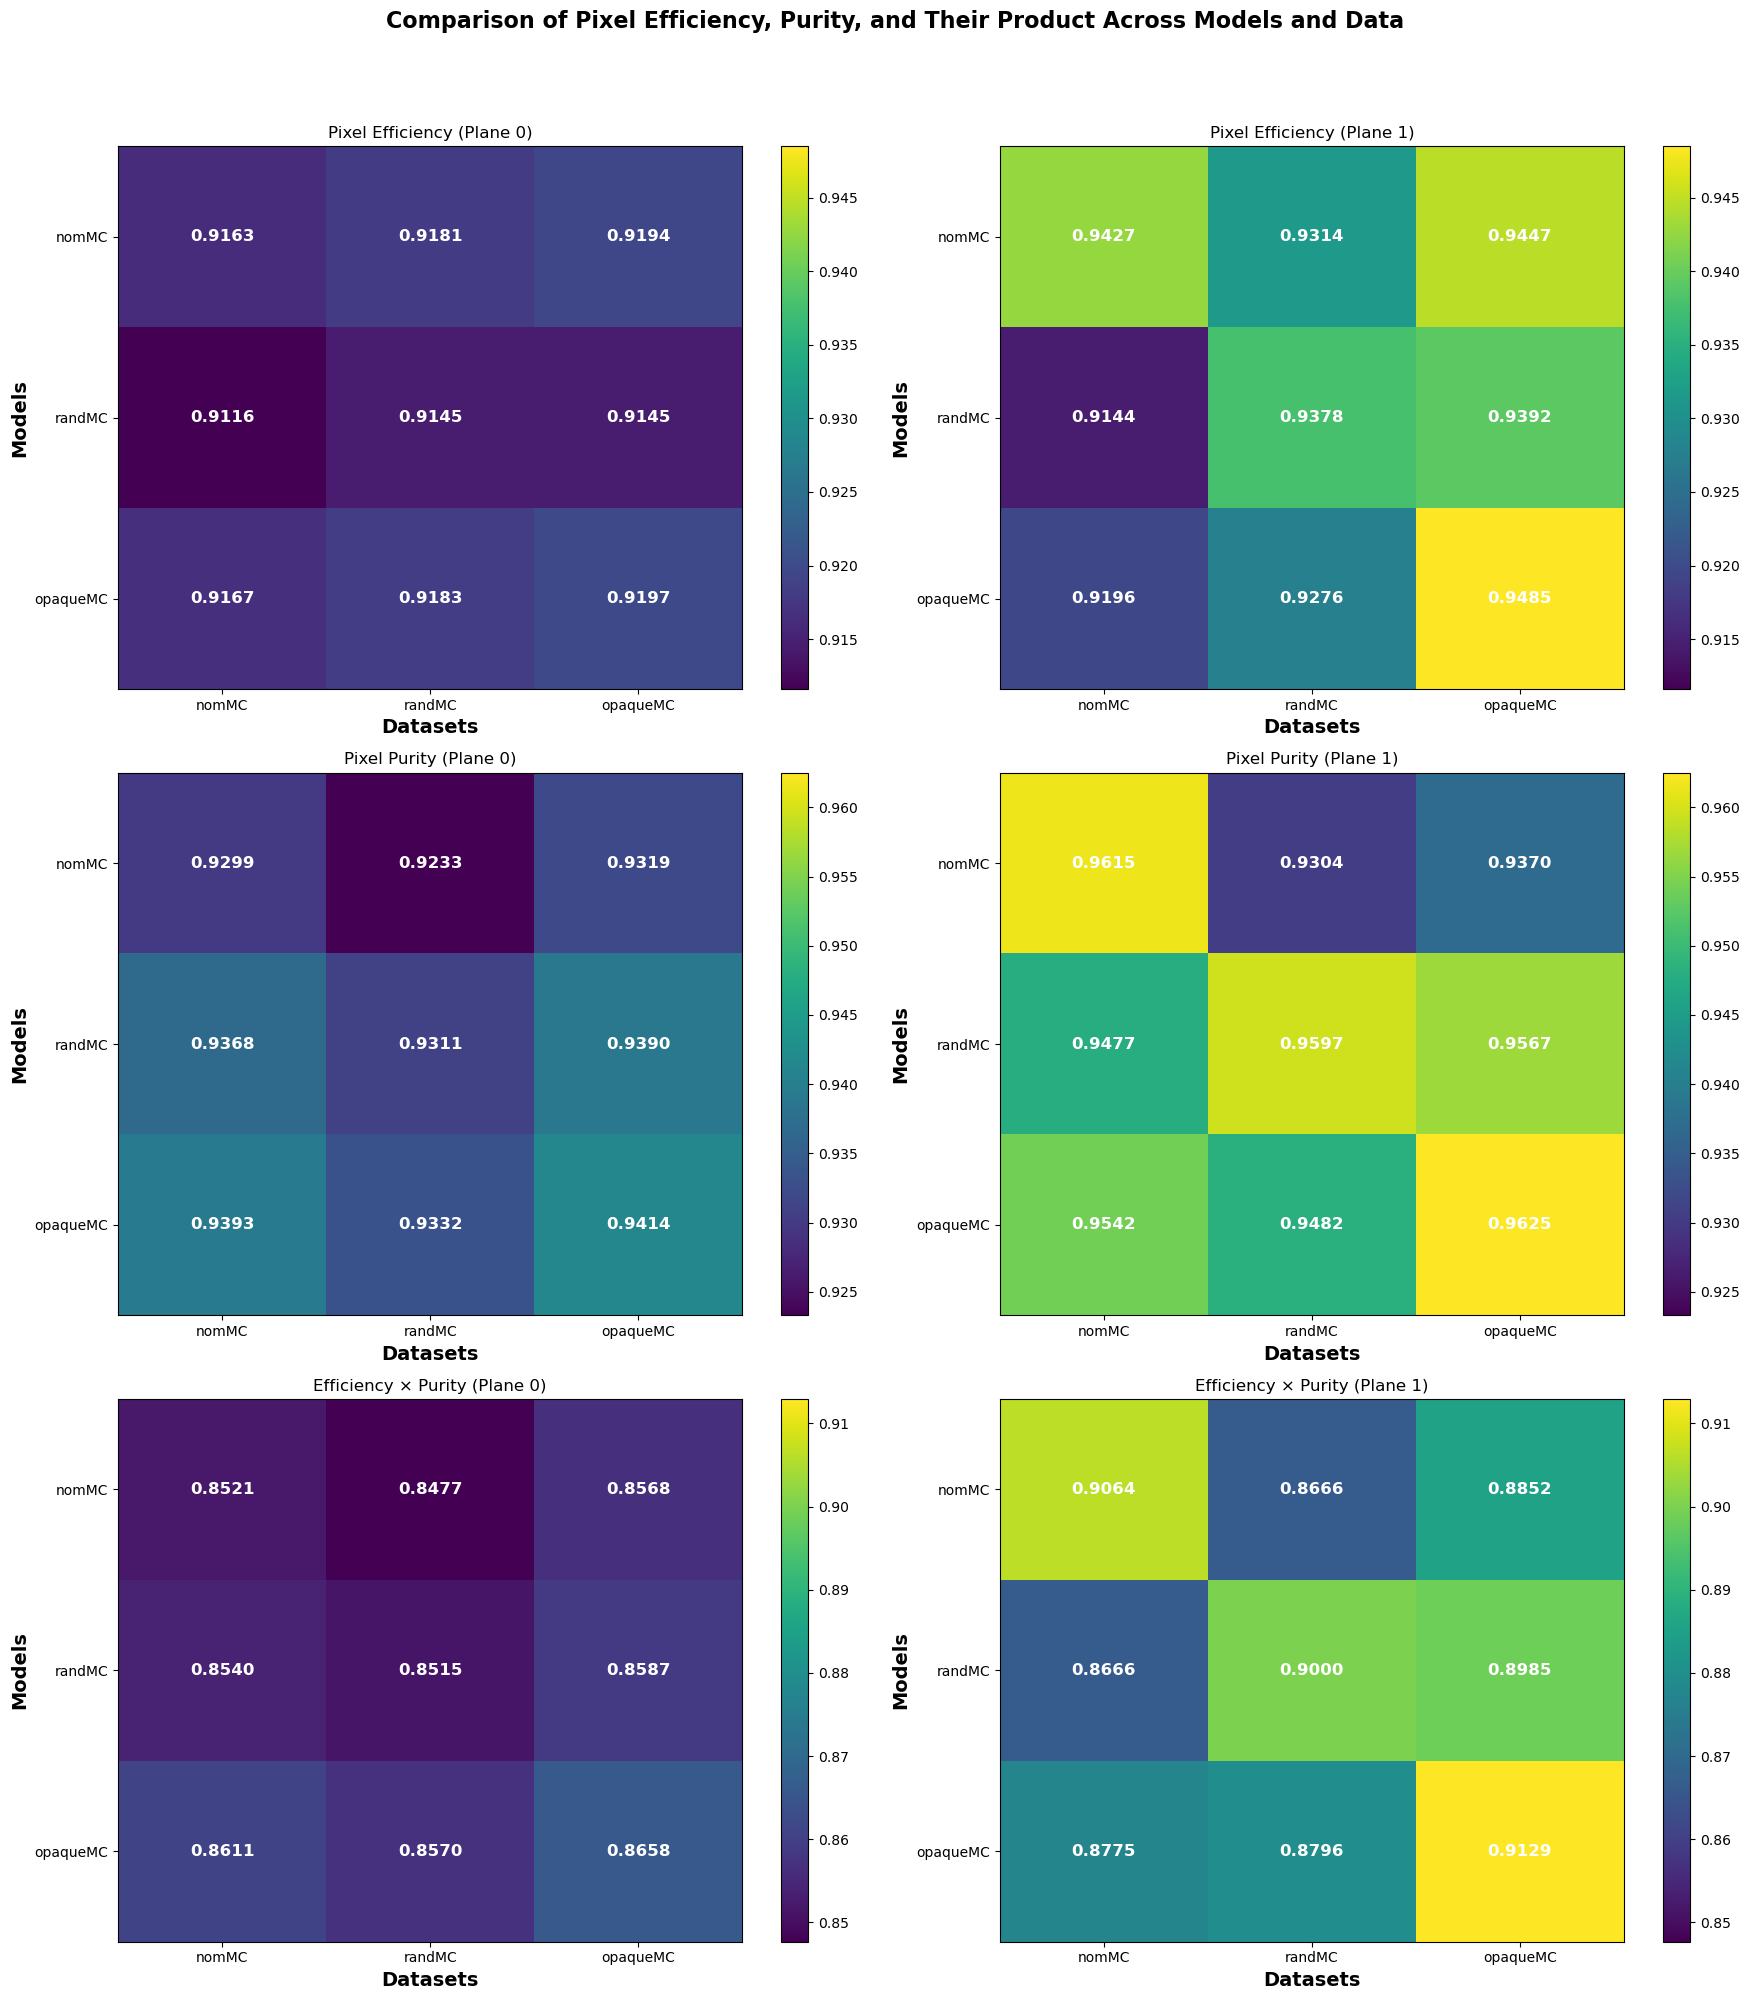

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Define the path to your CSV files and labels
models = ["nomMC", "randMC", "opaqueMC"]
data_types = ["nomMC", "randMC", "opaqueMC"]

# Initialize matrices for pixel efficiency, pixel purity, and their product
efficiency_plane0 = [[0] * 3 for _ in range(3)]
purity_plane0 = [[0] * 3 for _ in range(3)]
product_plane0 = [[0] * 3 for _ in range(3)]

efficiency_plane1 = [[0] * 3 for _ in range(3)]
purity_plane1 = [[0] * 3 for _ in range(3)]
product_plane1 = [[0] * 3 for _ in range(3)]

# Helper function to extract efficiency and purity
def extract_values(csv_file):
    df = pd.read_csv(csv_file, header=None)
    last_row = df.iloc[-1]
    pixel_efficiency = float(last_row[1])
    pixel_purity = float(last_row[2])
    return pixel_efficiency, pixel_purity

# Populate matrices with extracted values
for model_idx, model in enumerate(models):
    for data_idx, data in enumerate(data_types):
        for plane in [0, 1]:
            csv_file = f"/home/abhat/wirecell_icarus/Pytorch-UNet/out-eval/UNet_model_{model}_eval_{data}_Plane{plane}-u.csv"
            try:
                efficiency, purity = extract_values(csv_file)
                if plane == 0:
                    efficiency_plane0[model_idx][data_idx] = efficiency
                    purity_plane0[model_idx][data_idx] = purity
                    product_plane0[model_idx][data_idx] = efficiency * purity
                else:
                    efficiency_plane1[model_idx][data_idx] = efficiency
                    purity_plane1[model_idx][data_idx] = purity
                    product_plane1[model_idx][data_idx] = efficiency * purity
            except Exception as e:
                print(f"Error processing file {csv_file}: {e}")

# Determine the color scale range for pixel efficiency, purity, and their product
min_efficiency = min(min(map(min, efficiency_plane0)), min(map(min, efficiency_plane1)))
max_efficiency = max(max(map(max, efficiency_plane0)), max(map(max, efficiency_plane1)))

min_purity = min(min(map(min, purity_plane0)), min(map(min, purity_plane1)))
max_purity = max(max(map(max, purity_plane0)), max(map(max, purity_plane1)))

min_product = min(min(map(min, product_plane0)), min(map(min, product_plane1)))
max_product = max(max(map(max, product_plane0)), max(map(max, product_plane1)))

# Define a function to create heatmap plots with consistent color scales and labeled axes
def plot_heatmap(data, title, ax, vmin, vmax):
    im = ax.imshow(data, cmap='viridis', aspect='auto', vmin=vmin, vmax=vmax)
    ax.set_xticks(range(3))
    ax.set_yticks(range(3))
    ax.set_xticklabels(data_types)
    ax.set_yticklabels(models)
    ax.set_title(title)

    # Annotate each square with the value
    for i in range(3):
        for j in range(3):
            text = ax.text(j, i, f"{data[i][j]:.4f}",
                           ha="center", va="center", color="white", fontsize=12, fontweight='bold')

    # Label axes
    ax.set_xlabel("Datasets", fontsize=14, fontweight='bold')
    ax.set_ylabel("Models", fontsize=14, fontweight='bold')

    # Add colorbar
    plt.colorbar(im, ax=ax)

# Create subplots with increased size
fig, axes = plt.subplots(3, 2, figsize=(18, 21))

# Plot Pixel Efficiency for Plane 0 and Plane 1 with the same color range
plot_heatmap(efficiency_plane0, "Pixel Efficiency (Plane 0)", axes[0, 0], min_efficiency, max_efficiency)
plot_heatmap(efficiency_plane1, "Pixel Efficiency (Plane 1)", axes[0, 1], min_efficiency, max_efficiency)

# Plot Pixel Purity for Plane 0 and Plane 1 with the same color range
plot_heatmap(purity_plane0, "Pixel Purity (Plane 0)", axes[1, 0], min_purity, max_purity)
plot_heatmap(purity_plane1, "Pixel Purity (Plane 1)", axes[1, 1], min_purity, max_purity)

# Plot Product of Pixel Efficiency and Purity for Plane 0 and Plane 1 with the same color range
plot_heatmap(product_plane0, "Efficiency × Purity (Plane 0)", axes[2, 0], min_product, max_product)
plot_heatmap(product_plane1, "Efficiency × Purity (Plane 1)", axes[2, 1], min_product, max_product)

# Adjust layout and add overall figure labels
fig.suptitle("Comparison of Pixel Efficiency, Purity, and Their Product Across Models and Data", fontsize=16, fontweight='bold')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig('eff_pur_matrix_mul.pdf',dpi=500)

plt.show()


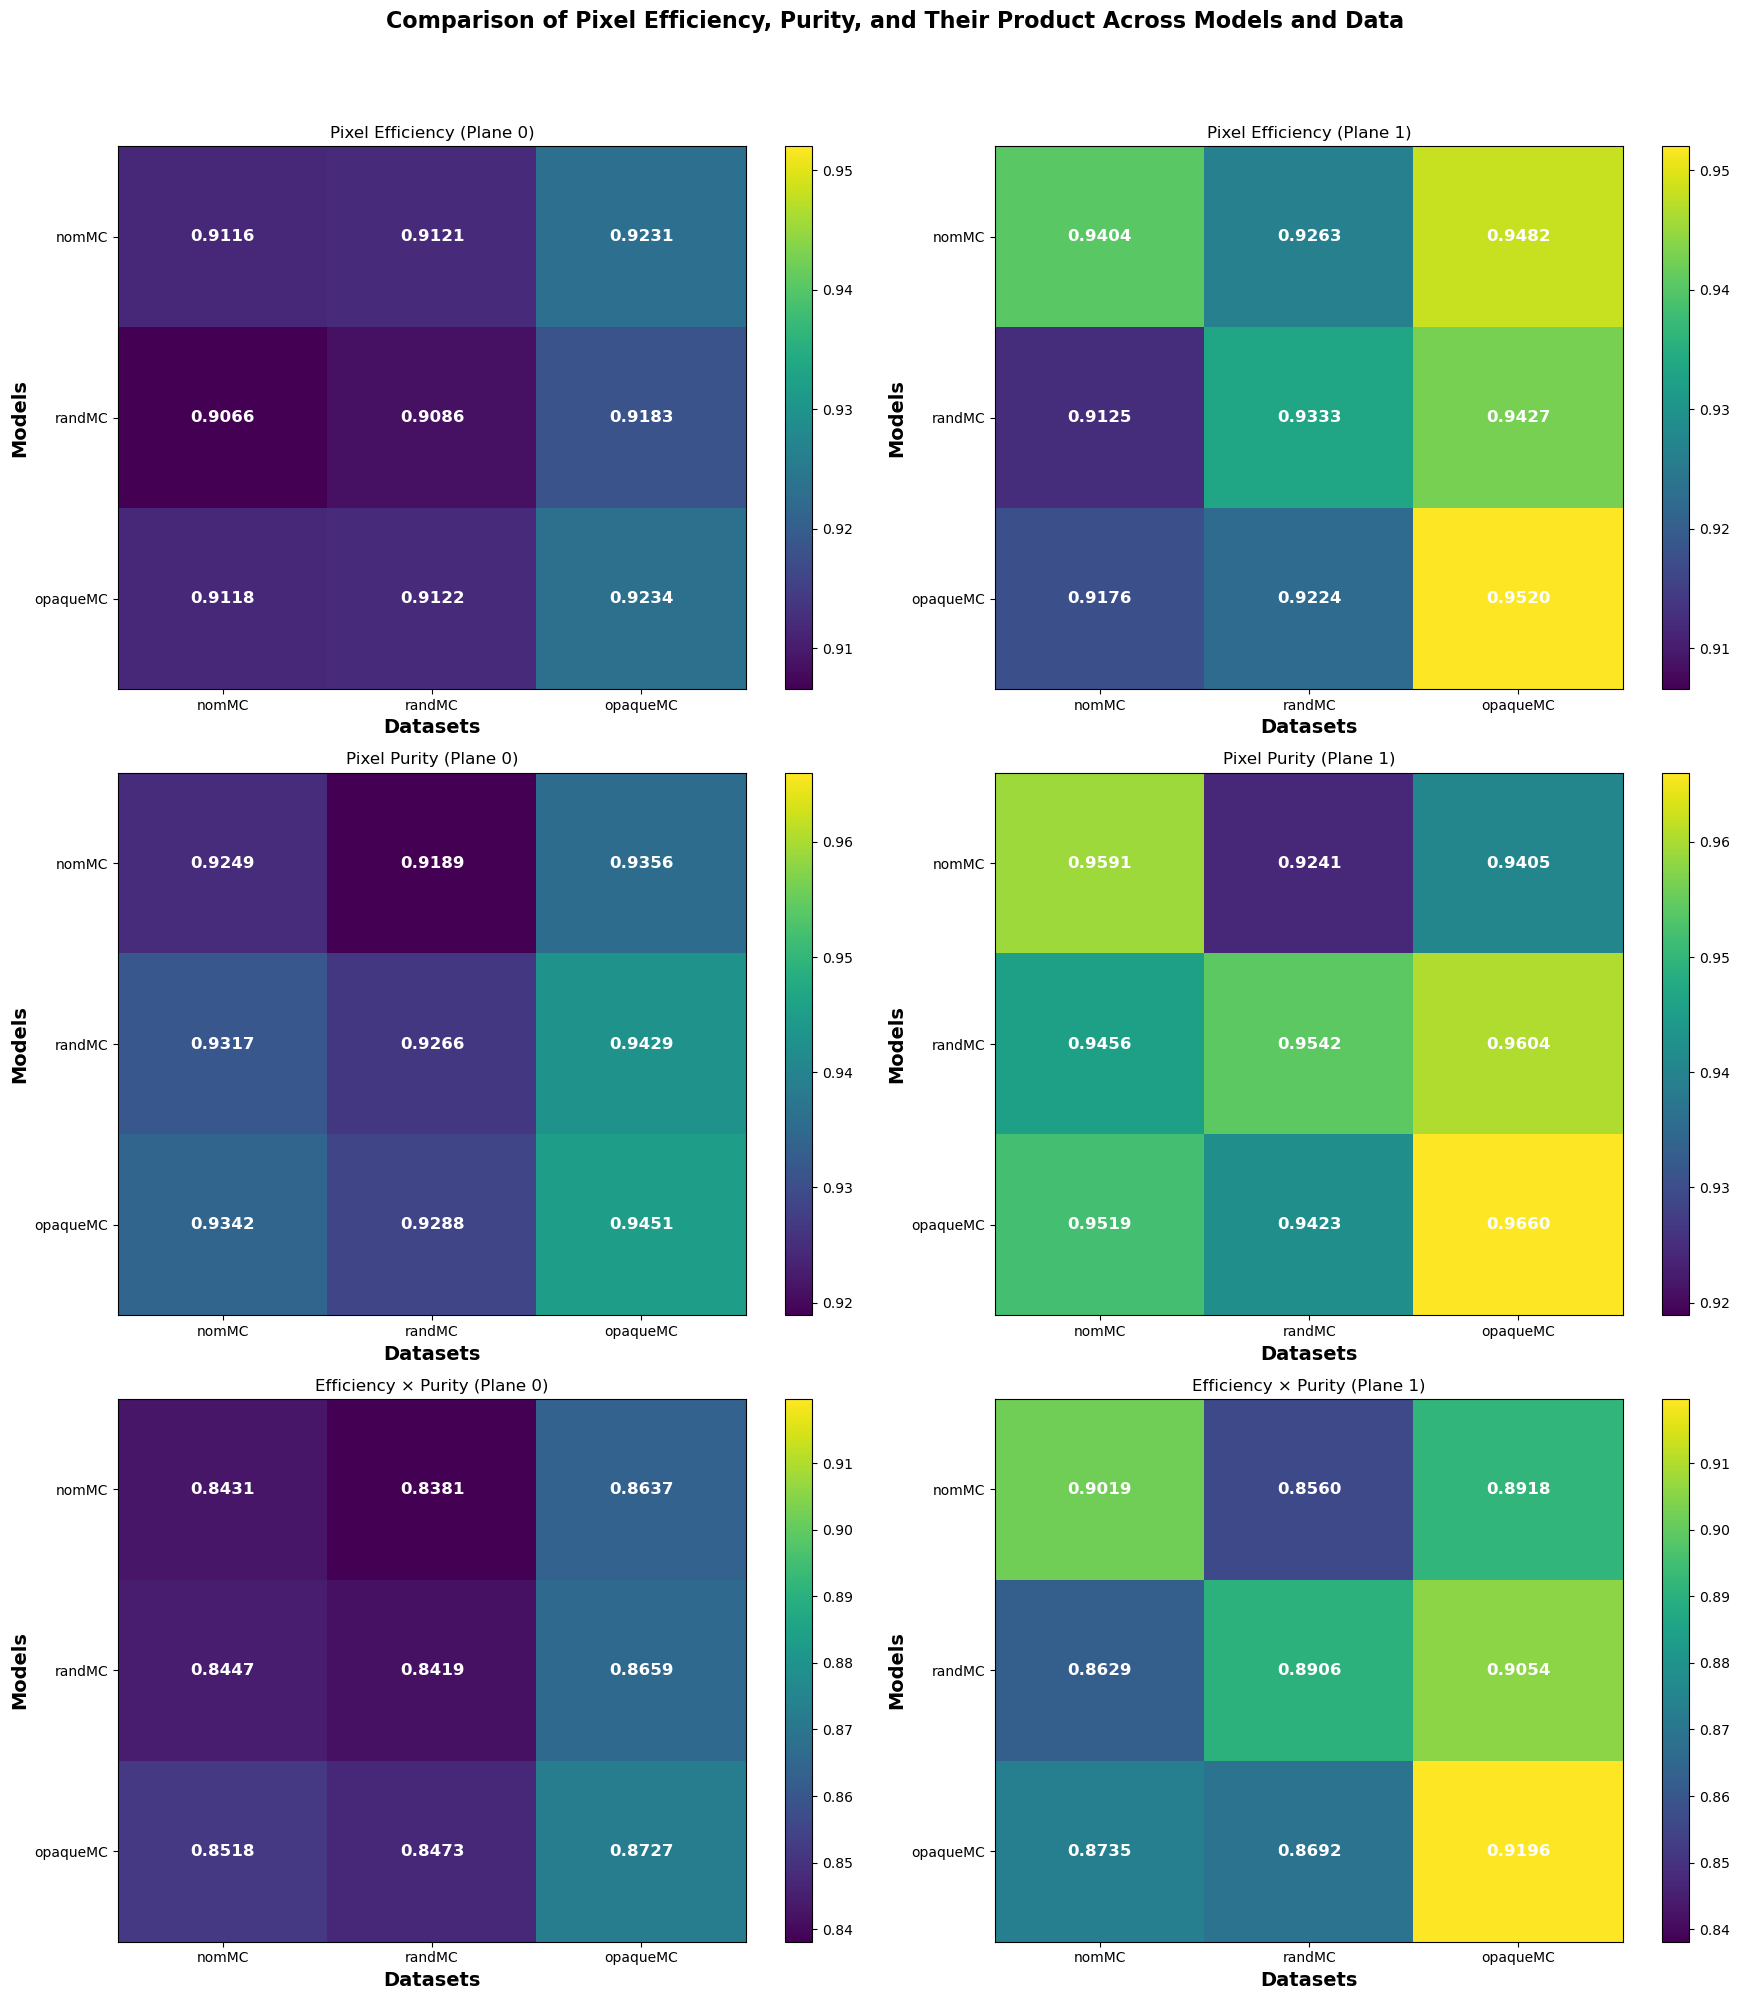

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# Define the path to your CSV files and labels
models = ["nomMC", "randMC", "opaqueMC"]
data_types = ["nomMC", "randMC", "opaqueMC"]

# Initialize matrices for pixel efficiency, pixel purity, and their product
efficiency_plane0 = [[0] * 3 for _ in range(3)]
purity_plane0 = [[0] * 3 for _ in range(3)]
product_plane0 = [[0] * 3 for _ in range(3)]

efficiency_plane1 = [[0] * 3 for _ in range(3)]
purity_plane1 = [[0] * 3 for _ in range(3)]
product_plane1 = [[0] * 3 for _ in range(3)]

# Helper function to extract efficiency and purity
def extract_values(csv_file):
    df = pd.read_csv(csv_file, header=None)
    last_row = df.iloc[-1]
    pixel_efficiency = float(last_row[1])
    pixel_purity = float(last_row[2])
    return pixel_efficiency, pixel_purity

# Populate matrices with extracted values
for model_idx, model in enumerate(models):
    for data_idx, data in enumerate(data_types):
        for plane in [0, 1]:
            csv_file = f"/home/abhat/wirecell_icarus/Pytorch-UNet/out-eval/0_800/UNet_model_{model}_eval_{data}_Plane{plane}-u.csv"
            try:
                efficiency, purity = extract_values(csv_file)
                if plane == 0:
                    efficiency_plane0[model_idx][data_idx] = efficiency
                    purity_plane0[model_idx][data_idx] = purity
                    product_plane0[model_idx][data_idx] = efficiency * purity
                else:
                    efficiency_plane1[model_idx][data_idx] = efficiency
                    purity_plane1[model_idx][data_idx] = purity
                    product_plane1[model_idx][data_idx] = efficiency * purity
            except Exception as e:
                print(f"Error processing file {csv_file}: {e}")

# Determine the color scale range for pixel efficiency, purity, and their product
min_efficiency = min(min(map(min, efficiency_plane0)), min(map(min, efficiency_plane1)))
max_efficiency = max(max(map(max, efficiency_plane0)), max(map(max, efficiency_plane1)))

min_purity = min(min(map(min, purity_plane0)), min(map(min, purity_plane1)))
max_purity = max(max(map(max, purity_plane0)), max(map(max, purity_plane1)))

min_product = min(min(map(min, product_plane0)), min(map(min, product_plane1)))
max_product = max(max(map(max, product_plane0)), max(map(max, product_plane1)))

# Define a function to create heatmap plots with consistent color scales and labeled axes
def plot_heatmap(data, title, ax, vmin, vmax):
    im = ax.imshow(data, cmap='viridis', aspect='auto', vmin=vmin, vmax=vmax)
    ax.set_xticks(range(3))
    ax.set_yticks(range(3))
    ax.set_xticklabels(data_types)
    ax.set_yticklabels(models)
    ax.set_title(title)

    # Annotate each square with the value
    for i in range(3):
        for j in range(3):
            text = ax.text(j, i, f"{data[i][j]:.4f}",
                           ha="center", va="center", color="white", fontsize=12, fontweight='bold')

    # Label axes
    ax.set_xlabel("Datasets", fontsize=14, fontweight='bold')
    ax.set_ylabel("Models", fontsize=14, fontweight='bold')

    # Add colorbar
    plt.colorbar(im, ax=ax)

# Create subplots with increased size
fig, axes = plt.subplots(3, 2, figsize=(18, 21))

# Plot Pixel Efficiency for Plane 0 and Plane 1 with the same color range
plot_heatmap(efficiency_plane0, "Pixel Efficiency (Plane 0)", axes[0, 0], min_efficiency, max_efficiency)
plot_heatmap(efficiency_plane1, "Pixel Efficiency (Plane 1)", axes[0, 1], min_efficiency, max_efficiency)

# Plot Pixel Purity for Plane 0 and Plane 1 with the same color range
plot_heatmap(purity_plane0, "Pixel Purity (Plane 0)", axes[1, 0], min_purity, max_purity)
plot_heatmap(purity_plane1, "Pixel Purity (Plane 1)", axes[1, 1], min_purity, max_purity)

# Plot Product of Pixel Efficiency and Purity for Plane 0 and Plane 1 with the same color range
plot_heatmap(product_plane0, "Efficiency × Purity (Plane 0)", axes[2, 0], min_product, max_product)
plot_heatmap(product_plane1, "Efficiency × Purity (Plane 1)", axes[2, 1], min_product, max_product)

# Adjust layout and add overall figure labels
fig.suptitle("Comparison of Pixel Efficiency, Purity, and Their Product Across Models and Data", fontsize=16, fontweight='bold')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig('eff_pur_matrix_mul_0_800.pdf',dpi=500)

plt.show()


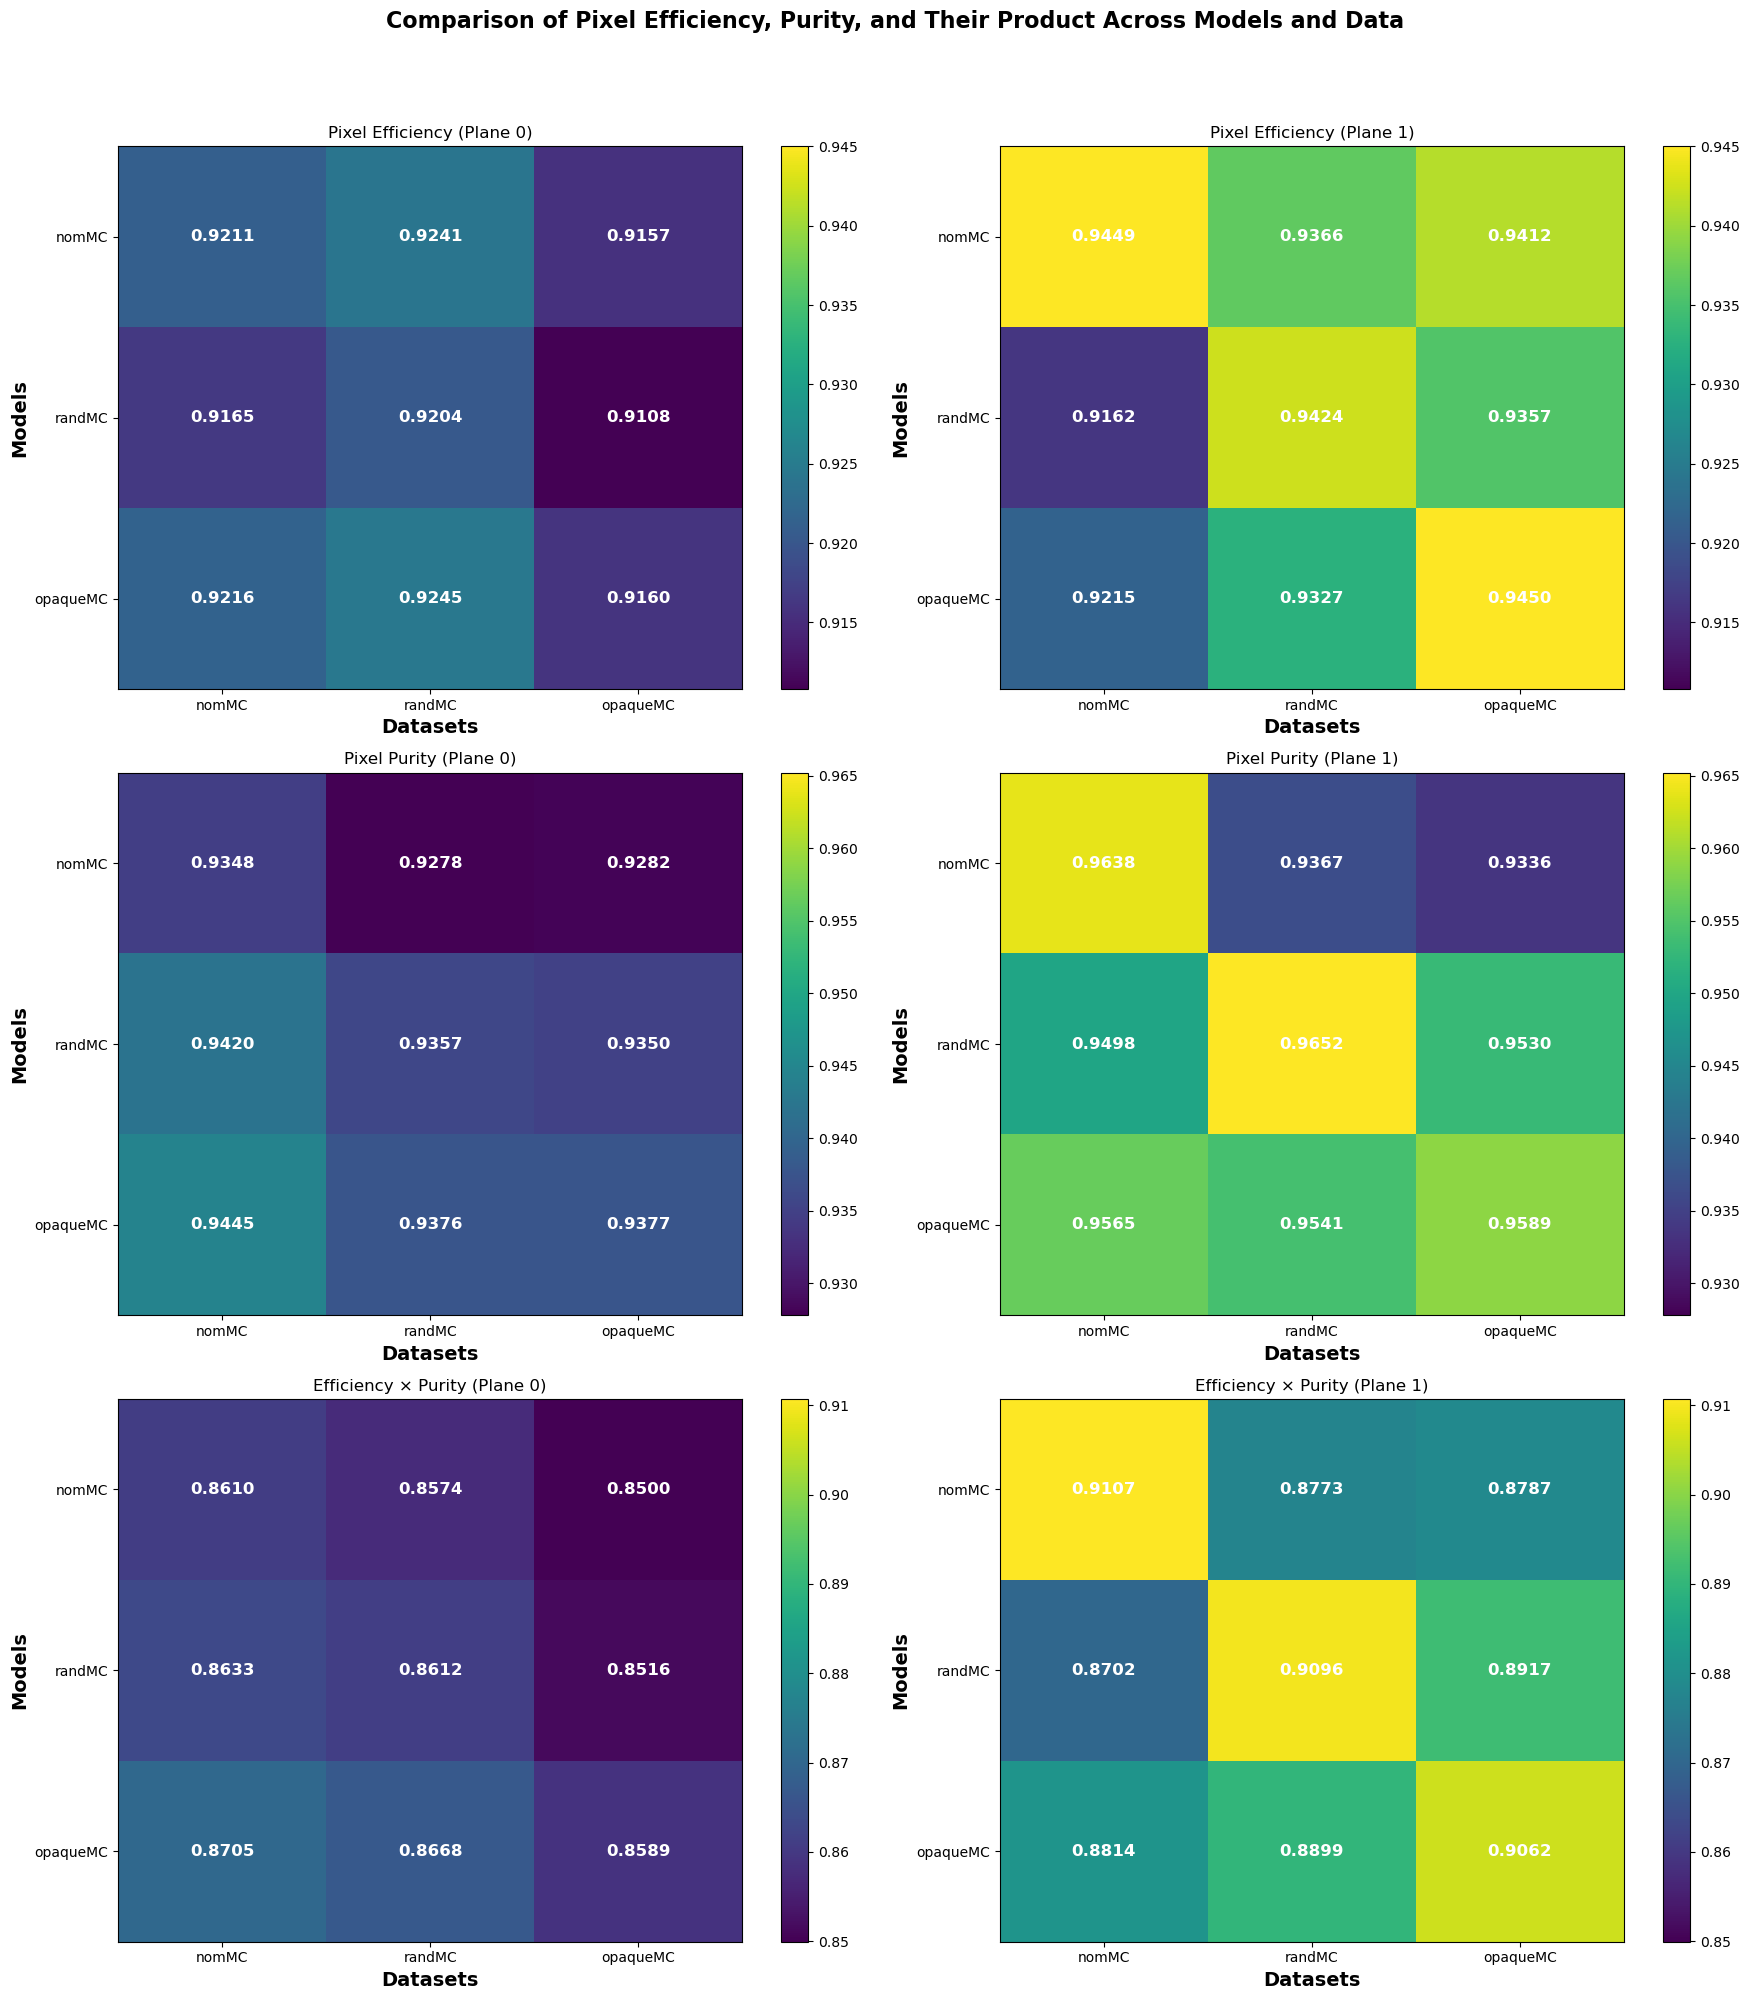

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

# Define the path to your CSV files and labels
models = ["nomMC", "randMC", "opaqueMC"]
data_types = ["nomMC", "randMC", "opaqueMC"]

# Initialize matrices for pixel efficiency, pixel purity, and their product
efficiency_plane0 = [[0] * 3 for _ in range(3)]
purity_plane0 = [[0] * 3 for _ in range(3)]
product_plane0 = [[0] * 3 for _ in range(3)]

efficiency_plane1 = [[0] * 3 for _ in range(3)]
purity_plane1 = [[0] * 3 for _ in range(3)]
product_plane1 = [[0] * 3 for _ in range(3)]

# Helper function to extract efficiency and purity
def extract_values(csv_file):
    df = pd.read_csv(csv_file, header=None)
    last_row = df.iloc[-1]
    pixel_efficiency = float(last_row[1])
    pixel_purity = float(last_row[2])
    return pixel_efficiency, pixel_purity

# Populate matrices with extracted values
for model_idx, model in enumerate(models):
    for data_idx, data in enumerate(data_types):
        for plane in [0, 1]:
            csv_file = f"/home/abhat/wirecell_icarus/Pytorch-UNet/out-eval/800_1600/UNet_model_{model}_eval_{data}_Plane{plane}-u.csv"
            try:
                efficiency, purity = extract_values(csv_file)
                if plane == 0:
                    efficiency_plane0[model_idx][data_idx] = efficiency
                    purity_plane0[model_idx][data_idx] = purity
                    product_plane0[model_idx][data_idx] = efficiency * purity
                else:
                    efficiency_plane1[model_idx][data_idx] = efficiency
                    purity_plane1[model_idx][data_idx] = purity
                    product_plane1[model_idx][data_idx] = efficiency * purity
            except Exception as e:
                print(f"Error processing file {csv_file}: {e}")

# Determine the color scale range for pixel efficiency, purity, and their product
min_efficiency = min(min(map(min, efficiency_plane0)), min(map(min, efficiency_plane1)))
max_efficiency = max(max(map(max, efficiency_plane0)), max(map(max, efficiency_plane1)))

min_purity = min(min(map(min, purity_plane0)), min(map(min, purity_plane1)))
max_purity = max(max(map(max, purity_plane0)), max(map(max, purity_plane1)))

min_product = min(min(map(min, product_plane0)), min(map(min, product_plane1)))
max_product = max(max(map(max, product_plane0)), max(map(max, product_plane1)))

# Define a function to create heatmap plots with consistent color scales and labeled axes
def plot_heatmap(data, title, ax, vmin, vmax):
    im = ax.imshow(data, cmap='viridis', aspect='auto', vmin=vmin, vmax=vmax)
    ax.set_xticks(range(3))
    ax.set_yticks(range(3))
    ax.set_xticklabels(data_types)
    ax.set_yticklabels(models)
    ax.set_title(title)

    # Annotate each square with the value
    for i in range(3):
        for j in range(3):
            text = ax.text(j, i, f"{data[i][j]:.4f}",
                           ha="center", va="center", color="white", fontsize=12, fontweight='bold')

    # Label axes
    ax.set_xlabel("Datasets", fontsize=14, fontweight='bold')
    ax.set_ylabel("Models", fontsize=14, fontweight='bold')

    # Add colorbar
    plt.colorbar(im, ax=ax)

# Create subplots with increased size
fig, axes = plt.subplots(3, 2, figsize=(18, 21))

# Plot Pixel Efficiency for Plane 0 and Plane 1 with the same color range
plot_heatmap(efficiency_plane0, "Pixel Efficiency (Plane 0)", axes[0, 0], min_efficiency, max_efficiency)
plot_heatmap(efficiency_plane1, "Pixel Efficiency (Plane 1)", axes[0, 1], min_efficiency, max_efficiency)

# Plot Pixel Purity for Plane 0 and Plane 1 with the same color range
plot_heatmap(purity_plane0, "Pixel Purity (Plane 0)", axes[1, 0], min_purity, max_purity)
plot_heatmap(purity_plane1, "Pixel Purity (Plane 1)", axes[1, 1], min_purity, max_purity)

# Plot Product of Pixel Efficiency and Purity for Plane 0 and Plane 1 with the same color range
plot_heatmap(product_plane0, "Efficiency × Purity (Plane 0)", axes[2, 0], min_product, max_product)
plot_heatmap(product_plane1, "Efficiency × Purity (Plane 1)", axes[2, 1], min_product, max_product)

# Adjust layout and add overall figure labels
fig.suptitle("Comparison of Pixel Efficiency, Purity, and Their Product Across Models and Data", fontsize=16, fontweight='bold')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig('eff_pur_matrix_mul_800_1600.pdf',dpi=500)

plt.show()


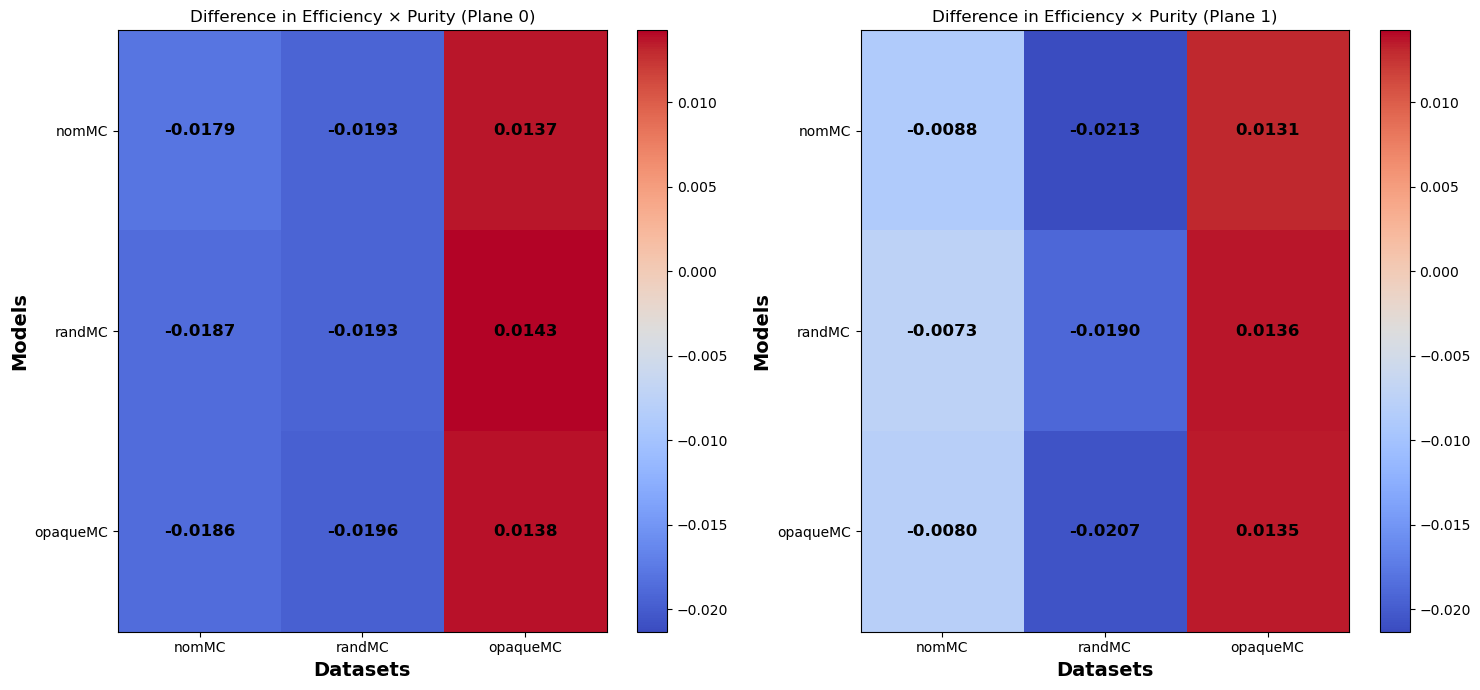


Paired t-test results for Plane 0: t-statistic = -1.4545, p-value = 1.8390e-01
Cohen's d (effect size) for Plane 0 = -0.4848

Paired t-test results for Plane 1: t-statistic = -1.0115, p-value = 3.4139e-01
Cohen's d (effect size) for Plane 1 = -0.3372


In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import ttest_rel

# Define paths to your CSV files for both datasets
base_path_0_800 = "/home/abhat/wirecell_icarus/Pytorch-UNet/out-eval/0_800/"
base_path_800_1600 = "/home/abhat/wirecell_icarus/Pytorch-UNet/out-eval/800_1600/"

models = ["nomMC", "randMC", "opaqueMC"]
data_types = ["nomMC", "randMC", "opaqueMC"]

# Initialize matrices for the product of pixel efficiency and purity difference
product_diff_plane0 = [[0] * 3 for _ in range(3)]
product_diff_plane1 = [[0] * 3 for _ in range(3)]

# Lists to store values for paired t-test and Cohen's d calculation
eff_pur_0_800_plane0 = []
eff_pur_800_1600_plane0 = []
eff_pur_0_800_plane1 = []
eff_pur_800_1600_plane1 = []

# Helper function to extract efficiency and purity
def extract_values(csv_file):
    df = pd.read_csv(csv_file, header=None)
    last_row = df.iloc[-1]
    pixel_efficiency = float(last_row[1])
    pixel_purity = float(last_row[2])
    return pixel_efficiency * pixel_purity

# Populate matrices with the difference of the products (0_800 - 800_1600)
for model_idx, model in enumerate(models):
    for data_idx, data in enumerate(data_types):
        for plane in [0, 1]:
            csv_file_0_800 = f"{base_path_0_800}UNet_model_{model}_eval_{data}_Plane{plane}-u.csv"
            csv_file_800_1600 = f"{base_path_800_1600}UNet_model_{model}_eval_{data}_Plane{plane}-u.csv"
            try:
                product_0_800 = extract_values(csv_file_0_800)
                product_800_1600 = extract_values(csv_file_800_1600)
                difference = product_0_800 - product_800_1600

                # Store the difference in the appropriate matrix
                if plane == 0:
                    product_diff_plane0[model_idx][data_idx] = difference
                    eff_pur_0_800_plane0.append(product_0_800)
                    eff_pur_800_1600_plane0.append(product_800_1600)
                else:
                    product_diff_plane1[model_idx][data_idx] = difference
                    eff_pur_0_800_plane1.append(product_0_800)
                    eff_pur_800_1600_plane1.append(product_800_1600)
            except Exception as e:
                print(f"Error processing files {csv_file_0_800} and {csv_file_800_1600}: {e}")

# Determine the color scale range for the difference plots
min_diff = min(min(map(min, product_diff_plane0)), min(map(min, product_diff_plane1)))
max_diff = max(max(map(max, product_diff_plane0)), max(map(max, product_diff_plane1)))

# Define a function to create heatmap plots with consistent color scales and labeled axes
def plot_heatmap(data, title, ax, vmin, vmax):
    im = ax.imshow(data, cmap='coolwarm', aspect='auto', vmin=vmin, vmax=vmax)
    ax.set_xticks(range(3))
    ax.set_yticks(range(3))
    ax.set_xticklabels(data_types)
    ax.set_yticklabels(models)
    ax.set_title(title)

    # Annotate each square with the value
    for i in range(3):
        for j in range(3):
            text = ax.text(j, i, f"{data[i][j]:.4f}",
                           ha="center", va="center", color="black", fontsize=12, fontweight='bold')

    # Label axes
    ax.set_xlabel("Datasets", fontsize=14, fontweight='bold')
    ax.set_ylabel("Models", fontsize=14, fontweight='bold')

    # Add colorbar
    plt.colorbar(im, ax=ax)

# Create subplots
fig, axes = plt.subplots(1, 2, figsize=(15, 7))

# Plot the difference of Efficiency × Purity for Plane 0 and Plane 1
plot_heatmap(product_diff_plane0, "Difference in Efficiency × Purity (Plane 0)", axes[0], min_diff, max_diff)
plot_heatmap(product_diff_plane1, "Difference in Efficiency × Purity (Plane 1)", axes[1], min_diff, max_diff)

# Adjust layout and display the plot
plt.tight_layout()
plt.savefig('difference.pdf', dpi=500)
plt.show()

# Paired t-test and Effect Size (Cohen's d) Analysis
def paired_ttest_and_cohens_d(values_0_800, values_800_1600, plane):
    # Perform paired t-test
    t_stat, p_value = ttest_rel(values_0_800, values_800_1600)
    print(f"\nPaired t-test results for Plane {plane}: t-statistic = {t_stat:.4f}, p-value = {p_value:.4e}")

    # Calculate Cohen's d for effect size
    diff = np.array(values_0_800) - np.array(values_800_1600)
    cohen_d = np.mean(diff) / np.std(diff, ddof=1)
    print(f"Cohen's d (effect size) for Plane {plane} = {cohen_d:.4f}")

# Perform statistical analysis for both planes
paired_ttest_and_cohens_d(eff_pur_0_800_plane0, eff_pur_800_1600_plane0, plane=0)
paired_ttest_and_cohens_d(eff_pur_0_800_plane1, eff_pur_800_1600_plane1, plane=1)


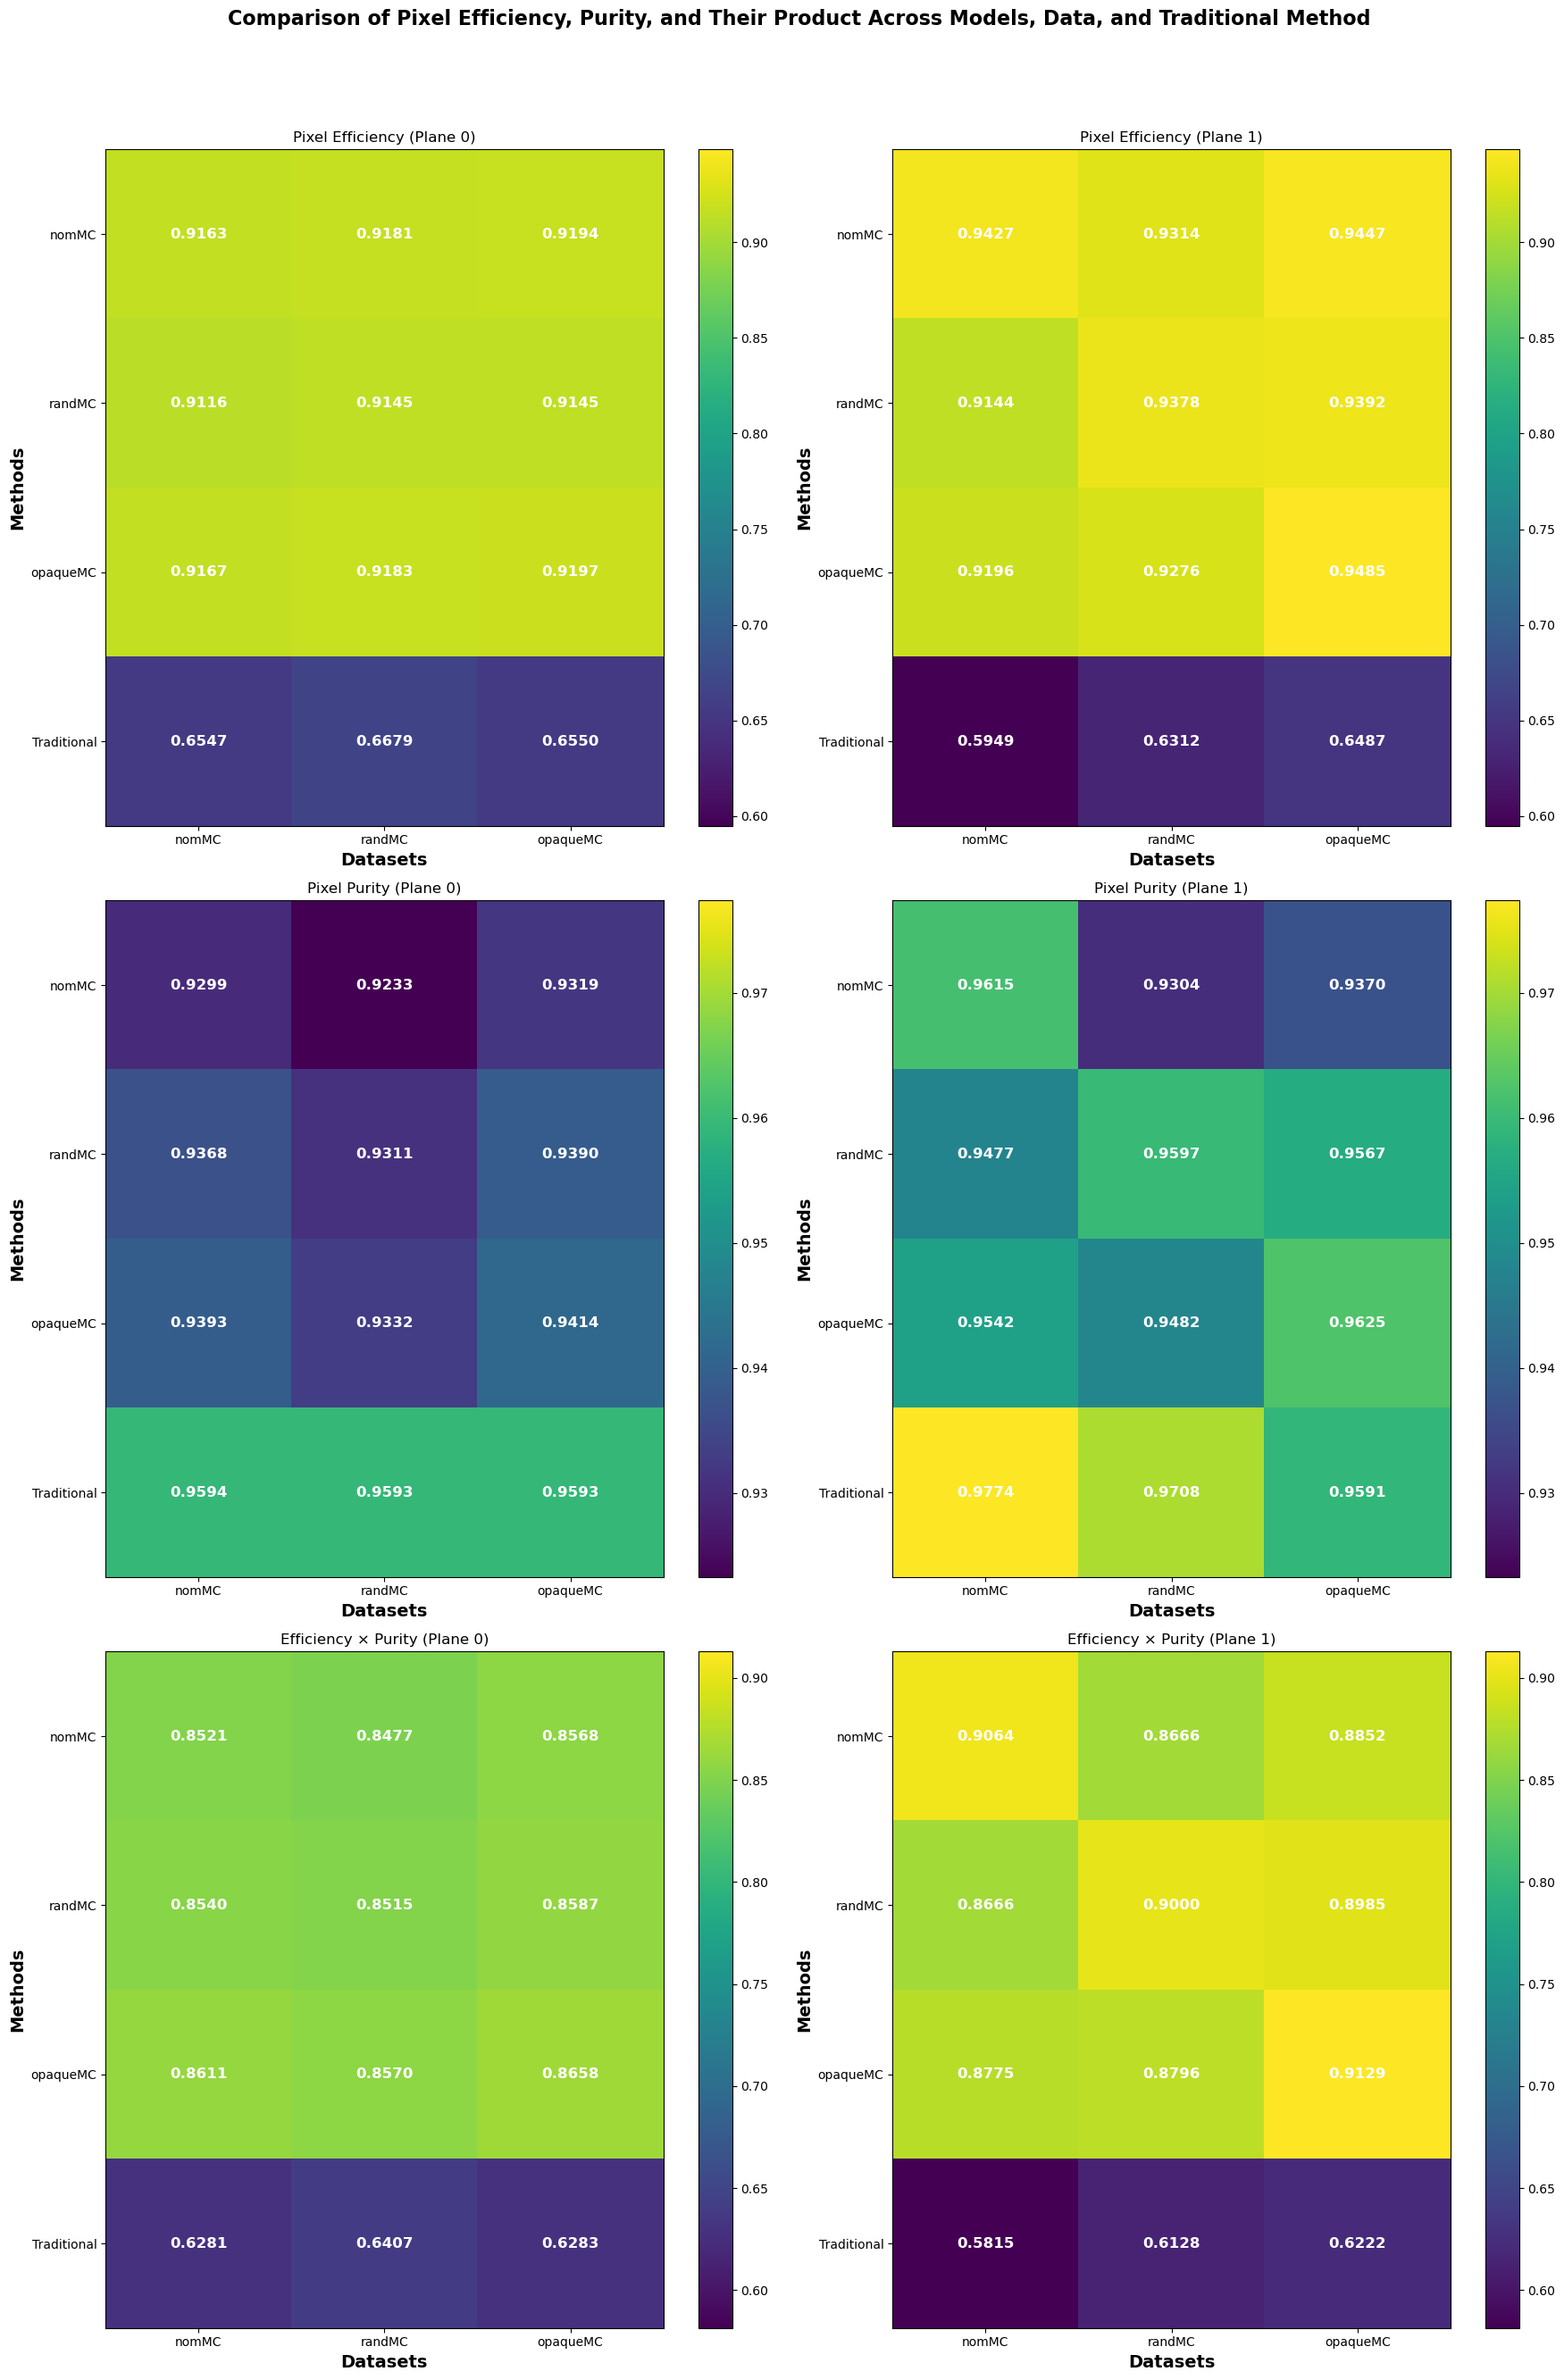

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

# Define the path to your CSV files and labels
models = ["nomMC", "randMC", "opaqueMC"]
data_types = ["nomMC", "randMC", "opaqueMC"]
methods = ["DNN", "Traditional"]

# Initialize matrices for pixel efficiency, pixel purity, and their product
efficiency_plane0 = [[0] * 3 for _ in range(4)]
purity_plane0 = [[0] * 3 for _ in range(4)]
product_plane0 = [[0] * 3 for _ in range(4)]

efficiency_plane1 = [[0] * 3 for _ in range(4)]
purity_plane1 = [[0] * 3 for _ in range(4)]
product_plane1 = [[0] * 3 for _ in range(4)]

# Helper function to extract efficiency and purity
def extract_values(csv_file):
    df = pd.read_csv(csv_file, header=None)
    last_row = df.iloc[-1]
    pixel_efficiency = float(last_row[1])
    pixel_purity = float(last_row[2])
    return pixel_efficiency, pixel_purity

# Populate matrices with extracted values for DNN
for model_idx, model in enumerate(models):
    for data_idx, data in enumerate(data_types):
        for plane in [0, 1]:
            csv_file = f"/home/abhat/wirecell_icarus/Pytorch-UNet/out-eval/UNet_model_{model}_eval_{data}_Plane{plane}-u.csv"
            try:
                efficiency, purity = extract_values(csv_file)
                if plane == 0:
                    efficiency_plane0[model_idx][data_idx] = efficiency
                    purity_plane0[model_idx][data_idx] = purity
                    product_plane0[model_idx][data_idx] = efficiency * purity
                else:
                    efficiency_plane1[model_idx][data_idx] = efficiency
                    purity_plane1[model_idx][data_idx] = purity
                    product_plane1[model_idx][data_idx] = efficiency * purity
            except Exception as e:
                print(f"Error processing file {csv_file}: {e}")

# Populate matrices with extracted values for Traditional
for data_idx, data in enumerate(data_types):
    for plane in [0, 1]:
        csv_file = f"/home/abhat/wirecell_icarus/Pytorch-UNet/out-eval/traditional/traditional_{data}_Plane{plane}.csv"
        try:
            efficiency, purity = extract_values(csv_file)
            if plane == 0:
                efficiency_plane0[3][data_idx] = efficiency
                purity_plane0[3][data_idx] = purity
                product_plane0[3][data_idx] = efficiency * purity
            else:
                efficiency_plane1[3][data_idx] = efficiency
                purity_plane1[3][data_idx] = purity
                product_plane1[3][data_idx] = efficiency * purity
        except Exception as e:
            print(f"Error processing file {csv_file}: {e}")

# Determine the color scale range for pixel efficiency, purity, and their product
min_efficiency = min(min(map(min, efficiency_plane0)), min(map(min, efficiency_plane1)))
max_efficiency = max(max(map(max, efficiency_plane0)), max(map(max, efficiency_plane1)))

min_purity = min(min(map(min, purity_plane0)), min(map(min, purity_plane1)))
max_purity = max(max(map(max, purity_plane0)), max(map(max, purity_plane1)))

min_product = min(min(map(min, product_plane0)), min(map(min, product_plane1)))
max_product = max(max(map(max, product_plane0)), max(map(max, product_plane1)))

# Define a function to create heatmap plots with consistent color scales and labeled axes
def plot_heatmap(data, title, ax, vmin, vmax):
    im = ax.imshow(data, cmap='viridis', aspect='auto', vmin=vmin, vmax=vmax)
    ax.set_xticks(range(3))
    ax.set_yticks(range(4))
    ax.set_xticklabels(data_types)
    ax.set_yticklabels(models + ["Traditional"])
    ax.set_title(title)

    # Annotate each square with the value
    for i in range(4):
        for j in range(3):
            text = ax.text(j, i, f"{data[i][j]:.4f}",
                           ha="center", va="center", color="white", fontsize=12, fontweight='bold')

    # Label axes
    ax.set_xlabel("Datasets", fontsize=14, fontweight='bold')
    ax.set_ylabel("Methods", fontsize=14, fontweight='bold')

    # Add colorbar
    plt.colorbar(im, ax=ax)

# Create subplots with increased size
fig, axes = plt.subplots(3, 2, figsize=(18, 28))

# Plot Pixel Efficiency for Plane 0 and Plane 1 with the same color range
plot_heatmap(efficiency_plane0, "Pixel Efficiency (Plane 0)", axes[0, 0], min_efficiency, max_efficiency)
plot_heatmap(efficiency_plane1, "Pixel Efficiency (Plane 1)", axes[0, 1], min_efficiency, max_efficiency)

# Plot Pixel Purity for Plane 0 and Plane 1 with the same color range
plot_heatmap(purity_plane0, "Pixel Purity (Plane 0)", axes[1, 0], min_purity, max_purity)
plot_heatmap(purity_plane1, "Pixel Purity (Plane 1)", axes[1, 1], min_purity, max_purity)

# Plot Product of Pixel Efficiency and Purity for Plane 0 and Plane 1 with the same color range
plot_heatmap(product_plane0, "Efficiency × Purity (Plane 0)", axes[2, 0], min_product, max_product)
plot_heatmap(product_plane1, "Efficiency × Purity (Plane 1)", axes[2, 1], min_product, max_product)

# Adjust layout and add overall figure labels
fig.suptitle("Comparison of Pixel Efficiency, Purity, and Their Product Across Models, Data, and Traditional Method", fontsize=16, fontweight='bold')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig('eff_pur_matrix_mul_with_traditional.pdf', dpi=500)

plt.show()
